# Exercise 1: Data Handling

### Read data and handle missing values

In [ ]:
import pandas as pd
import numpy as np

### Display summary statistics, and state the number of samples and features in the dataset.

In [ ]:
data = pd.read_excel("Tensile_Data.xlsx")

print("Shape: ", data.shape)

data.describe()

### Check if there are any missing values. If yes, remove the objects.

In [ ]:
data_drop_rows = data.copy()

if data_drop_rows.isnull().values.any():
    rows_dropped = data_drop_rows.shape[0] - data_drop_rows.dropna().shape[0]

    print("Missing values found")
    print("Rows dropped:", rows_dropped)

    data_drop_rows = data_drop_rows.dropna()

In [ ]:
print("\nShape AFTER dropping rows: ", data_drop_rows.shape, "\n\n")

data_drop_rows.describe()

### Remove the columns with missing values from original dataset

In [ ]:
data_drop_cols = data.copy()

data_drop_cols = data_drop_cols.dropna(axis=1)

print("Cols dropped: ", data_drop_cols.shape)

In [ ]:
data_drop_cols.describe()

## Exercise 2: Data Preparation

### Read data and handle missing values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data_read = pd.read_csv("NewYork_1980_data.csv")

print("Shape:", data_read.shape)

Shape: (48842, 15)


### Display summary statistics, and state the number of samples and features in the dataset.

In [2]:
print("Shape: ", data_read.shape, "\n\n")
data_read.describe()

Shape:  (48842, 15) 




,ID,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48803.000000,48842.000000
mean,24421.500000,38.643585,10.078089,1079.067626,87.459767,40.422382
std,14099.615261,13.710510,2.570973,7452.019058,402.918923,12.391444
min,1.000000,17.000000,1.000000,0.000000,0.000000,1.000000
25%,12211.250000,28.000000,9.000000,0.000000,0.000000,40.000000
50%,24421.500000,37.000000,10.000000,0.000000,0.000000,40.000000
75%,36631.750000,48.000000,12.000000,0.000000,0.000000,45.000000
max,48842.000000,90.000000,16.000000,99999.000000,4356.000000,99.000000


### Show the first 5 rows using head() and last 10 rows using tail()

In [3]:
data_read.head(5).iloc[:, -10:]

,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0.0,40,United-States,<=50K
1,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0.0,50,United-States,<=50K
2,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0.0,40,United-States,>50K
3,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0.0,40,United-States,>50K
4,Never-married,?,Own-child,White,Female,0,0.0,30,United-States,<=50K


### Check the counts for other columns. If there are any duplicate columns, remove them.

In [4]:
if data_read.columns.duplicated().any():
  print("Yes, duplicate columns exist")
else:
  print("No duplicate columns exist")

No duplicate columns exist


### Check if there are any missing values. If yes, remove the rows with missing values

In [5]:
print(data_read.isnull().sum(), "\n\n")

data_read_clean = data_read.copy()
data_read_clean = data_read_clean.dropna()

print("Shape after dropping rows:", data_read_clean.shape)

ID                 0
age                0
workclass          0
education          0
education-num      0
marital-status     0
occupation         0
relationship       0
race               0
sex               16
capital-gain       0
capital-loss      39
hours-per-week     0
native-country     0
income             0
dtype: int64 


Shape after dropping rows: (48787, 15)


### Check Feature Distribution

### Create a histogram plot of the numerical features using matplotlib

In [6]:
numerical_cols = ['age', 'hours-per-week']

### Plot the distributions of age and hours-per-week. Based on the plots, state the your observation about relationship between these two features for each object.

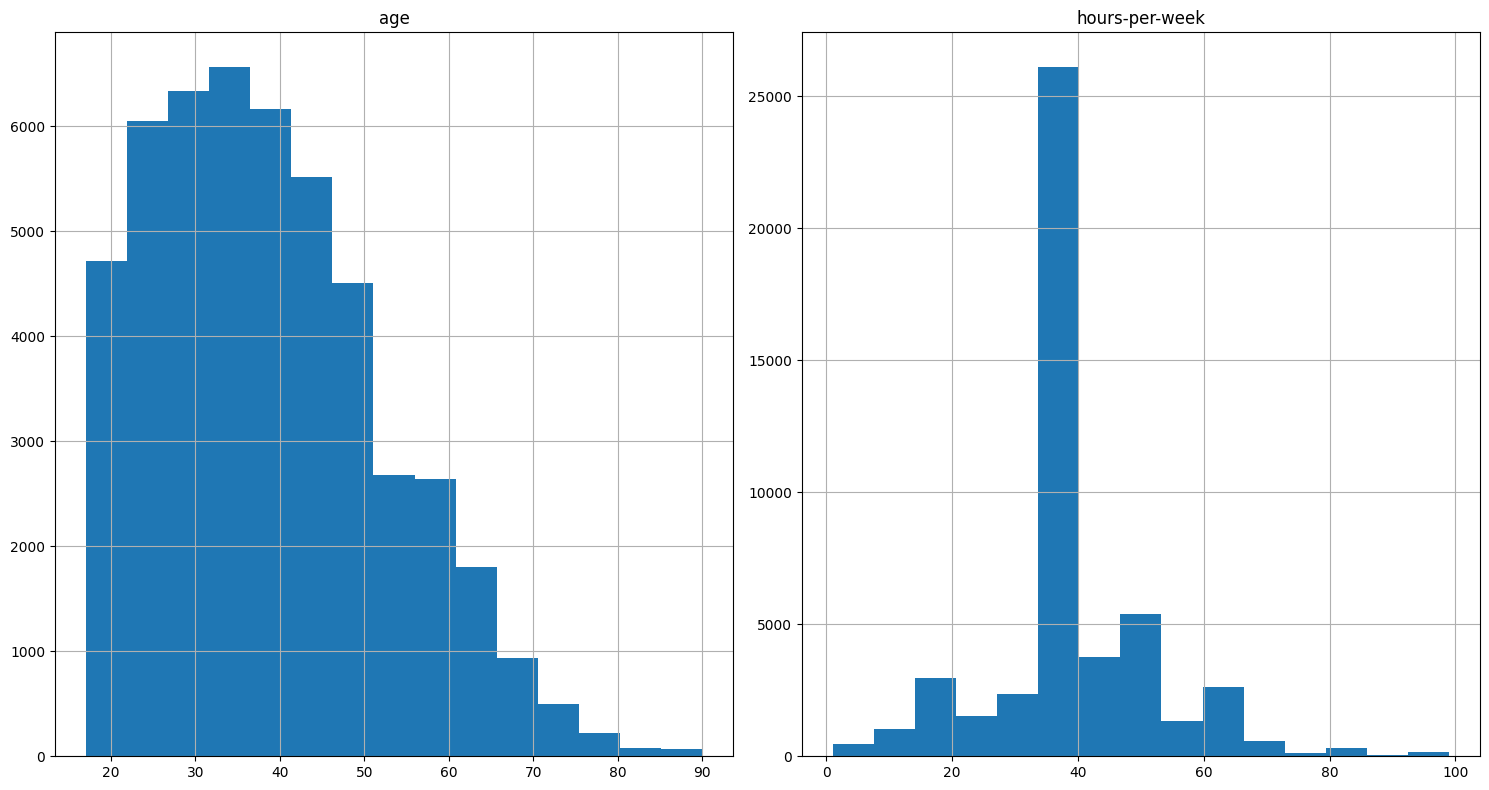

In [7]:
data_read_clean[numerical_cols].hist(figsize=(15, 8), bins=15)
plt.tight_layout()
plt.show()

### Encoding Categorical Features

### Use the Ordinal Encoder in scikit-learn to encode all columns with text data, except for the column income.

In [8]:
categorical_cols = ['workclass', 'education', 'marital-status',
                    'occupation', 'relationship', 'race',
                    'sex', 'native-country']

oe = OrdinalEncoder()
data_read_clean[categorical_cols] = oe.fit_transform(
                                    data_read_clean[categorical_cols])

### Use the Label Encoder in scikit-learn to encode the feature income.

In [9]:
le = LabelEncoder()
data_read_clean['income'] = le.fit_transform(data_read_clean['income'])

### Scaling Numerical Features

### Create target labels named y consisting of the income column, and a data label named X including all remaining columns.

In [10]:
print(data_read_clean[categorical_cols + ['income']].head())
# TODO: fix this

   workclass  education  marital-status  occupation  relationship  race  sex  \
0        4.0        1.0             4.0         7.0           3.0   2.0  1.0   
1        4.0       11.0             2.0         5.0           0.0   4.0  1.0   
2        2.0        7.0             2.0        11.0           0.0   4.0  1.0   
3        4.0       15.0             2.0         7.0           0.0   2.0  1.0   
4        0.0       15.0             4.0         0.0           3.0   4.0  0.0   

   native-country  income  
0            38.0       0  
1            38.0       0  
2            38.0       1  
3            38.0       1  
4            38.0       0  


### Use standardization to scale all columns in the data X to have 0 mean and 1 standard deviation.

In [11]:
y = data_read_clean['income']
X = data_read_clean.drop(columns=['income'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of each column (should be ~0):")
print(X_scaled.mean(axis=0).round(2))
print("\nStd of each column (should be ~1):")
print(X_scaled.std(axis=0).round(2))

Mean of each column (should be ~0):
[ 0. -0. -0. -0.  0. -0. -0. -0.  0.  0.  0.  0.  0.  0.]

Std of each column (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Sampling the dataset: Generate a new dataset with 300 objects using any 2 types of sample techniques

In [12]:
print(y.value_counts(normalize=True))

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

random_sample = X_scaled_df.sample(n=300, random_state=42)

print("Random sample shape:", random_sample.shape)
print("\n\nClass proportions:")
print(y[random_sample.index].value_counts(normalize=True))

income
0    0.760612
1    0.239388
Name: proportion, dtype: float64
Random sample shape: (300, 14)


Class proportions:
income
0    0.776667
1    0.223333
Name: proportion, dtype: float64


In [13]:
X_strat, _, y_strat, _ = train_test_split(
    X_scaled_df, y,
    test_size=len(X_scaled_df) - 300,
    stratify=y,
    random_state=42
)

print("Stratified sample shape:", X_strat.shape)
print("\n\nClass proportions:")
print(y_strat.value_counts(normalize=True))

Stratified sample shape: (300, 14)


Class proportions:
income
0    0.76
1    0.24
Name: proportion, dtype: float64
